In [1]:
%load_ext autoreload
%autoreload 2
from neuropy.analyses import correlations 
import numpy as np
import neuropy.analyses.ms_connectivity as msconn
import seaborn as sns
import matplotlib.pyplot as plt
import time
import subjects
skips = {} # epoch='post'
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([41,98])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([44,21])
skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','inter'))]=np.array([[129,125],[21,0],[139,66]])

Error importing CuPy
Error importing CuPy


/Users/selinl/miniforge3/envs/NeuroPy2/lib/python3.11/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
sess = subjects.nsd.allsess[5]
use_acceleration = False

In [ ]:
cconf=msconn.CCGConfig(use_acceleration=use_acceleration,normalize=msconn.NormalizeBy.BOTH_FRATE)
ndconf=msconn.NeuronsDatasetConfig(seg_stride=60*60*0.5, seg_len=60*60*5, epochs=['post'], sleep_labels=None,recinfo=sess.recinfo)
nd=msconn.NeuronsDataset(sess,ndconf)

In [ ]:
# get maximum number of significant pairs by using the whole dataset
cd=msconn.CCGDataset(nd,cconf)
cd.get_CCG_with_baseline()

EranConv significant pairs
running eranconv (1st pass)
running spike correlations
spike correlation done


In [ ]:
cd.set_connection_strengths(method="eran_conv")
cd.set_connectivity()

In [ ]:
cd.reCCG_timescale(bin_size=1e-4/3)

recalculated CCG from binsize=3.3333333333333335e-05 to binsize=3.3333333333333335e-05
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.seg_0.ex_E.type_pyr-pyr
running spike correlations
spike correlation done
done


KeyError: Key(session='RatU_Day2NSD', epoch='post', ref_ind=None, target_ind=None, segment=0, excitability='E', conn_type=('pyr', 'pyr'))

In [6]:
cd.conf=cconf
cd.reCCG_connectivity()

CCGDatasetConfig changed, which might create inconsistencies between existing data and config. Rerun if necessary.
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter
running spike correlations
spike correlation done
done
running eranconv (2nd pass): sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr
running spike correlations
spike correlation done
done
recomputed CCG for pairs that had been significant in any segment


In [7]:
cd.normalize()
cd.set_connection_strengths()
cd.set_connectivity()
# cd.example('connectivity')

In [8]:
skips = {} # epoch='post'
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','pyr'))]=np.array([[109, 182]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='E',conn_type=('pyr','inter'))]=np.array([[3, 129]])
# skips[msconn.Key(session='RatU_Day2NSD',epoch="post",excitability='I',conn_type=('inter','pyr'))]=np.array([[ 21,  59]])


sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


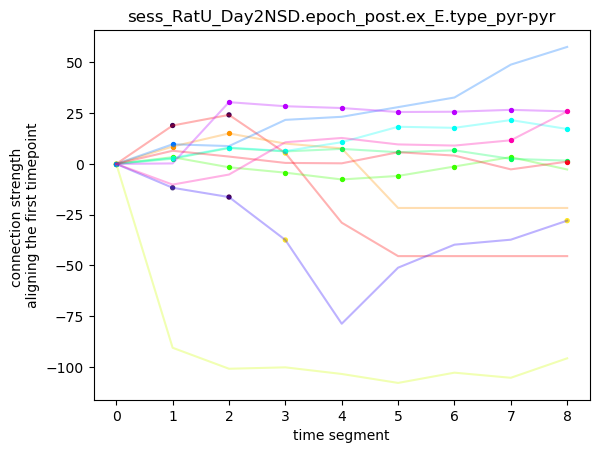

pvals [0.55495129 0.82643506 0.66574464 0.37972273 0.33308059 0.40193628
 0.50142188 0.64940877] threshold 0.00625 

mean values [-0.61081373 -0.22509963 -0.44507522 -0.91901249 -1.0171032  -0.8753173
 -0.69743746 -0.46859246] 

sess_RatU_Day2NSD.epoch_post.ex_E.type_pyr-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


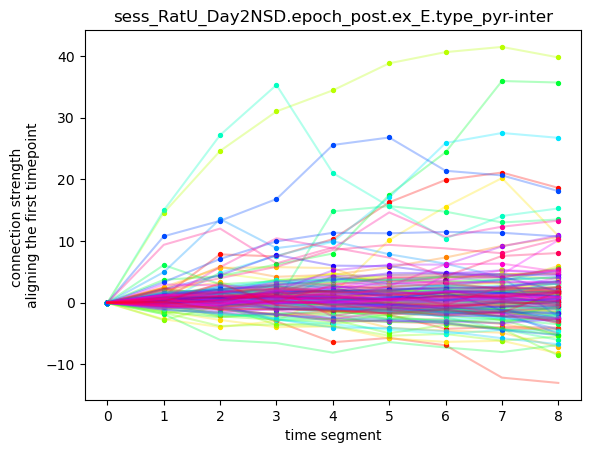

pvals [5.22674687e-05 5.39415881e-05 1.26429656e-04 6.96291747e-05
 1.78384397e-04 2.81910425e-04 7.70753493e-04 2.51448643e-03] threshold 0.00625 

mean values [4.16064535 4.15263707 3.9319225  4.08738393 3.84015948 3.71565066
 3.43063891 3.07138549] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-inter None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


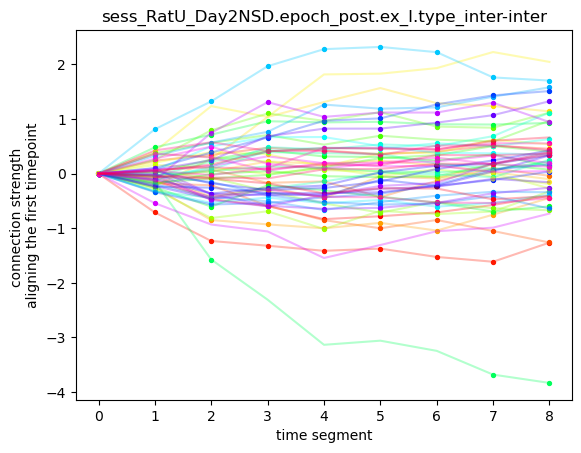

pvals [0.86233688 0.73148976 0.76776657 0.95746177 0.63720616 0.53893361
 0.31216309 0.14985591] threshold 0.00625 

mean values [-0.1742141  -0.34489368  0.29676132  0.05358273  0.47424007  0.61829416
  1.0200664   1.46044899] 

sess_RatU_Day2NSD.epoch_post.ex_I.type_inter-pyr None


/Users/selinl/Documents/NeuroPy/neuropy/analyses/ms_connectivity.py:1007: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_sig, v[x_sig], s=8, c=c,label="_nolegend_")


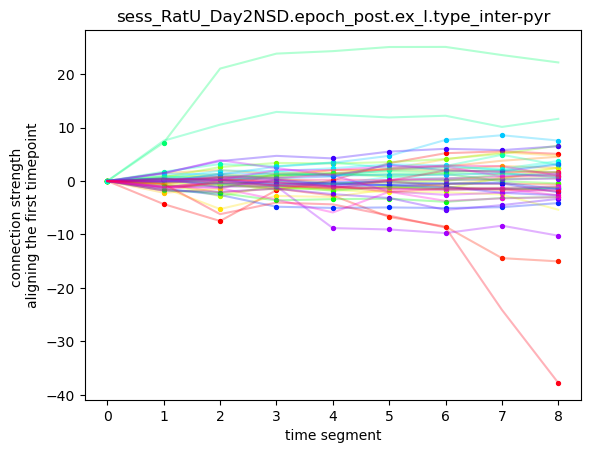

pvals [0.84537504 0.5335528  0.27861424 0.59429231 0.40217664 0.4229024
 0.72745826 0.99374588] threshold 0.00625 

mean values [0.19612649 0.62731744 1.09639165 0.53636288 0.8455574  0.80860928
 0.3506412  0.00788117] 



In [10]:
cd.plot_connection_strengths(show_legend=False,
                                norm_by_total_strength=False,
                                zero_first_timepoint=True,
                                norm_by_n_sess=False,
                                save=False,
                                root="/home/selinali/Documents/NeuroPy/images/conn_strength_1218_RefRateNorm/1-zero_first_timepoint",
                                skips=skips,
                                debug=False)

# individual plots

In [ ]:
_=cd.save_plots(root="~/Documents/NeuroPy/images/ccg_plots_0101",conn_types=[('pyr','inter')])